In [1]:
# Упражнение 2: Перплексия — от n-gram-и до трансформатори
# Сравняваме модели с различна токенизация и нормализираме до bits-per-character

In [2]:
import math
from collections import Counter

import torch
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["figure.figsize"] = (12, 4)

In [4]:
# Зареждаме корпуса на Шекспир
with open("../data/shakespeare.txt", "r") as f:
    text = f.read()

print(f"Размер: {len(text):,} символа")
print(text[10500:11000])

Размер: 5,458,199 символа

                     1
  From fairest creatures we desire increase,
  That thereby beauty's rose might never die,
  But as the riper should by time decease,
  His tender heir might bear his memory:
  But thou contracted to thine own bright eyes,
  Feed'st thy light's flame with self-substantial fuel,
  Making a famine where abundance lies,
  Thy self thy foe, to thy sweet self too cruel:
  Thou that art now the world's fresh ornament,
  And only herald to the gaudy spring,
  Within thine own bu


In [5]:
# Train/test разделяне + sample за сравнение на всички модели
split_idx = int(len(text) * 0.9)
train_text = text[:split_idx]
test_text = text[split_idx:]

SAMPLE_SIZE = 1500
sample = test_text[:SAMPLE_SIZE]
n_chars = len(sample)

print(f"Train: {len(train_text):,} символа")
print(f"Test:  {len(test_text):,} символа")
print(f"Sample: {n_chars:,} символа")
print(f"\n{sample[:200]}")

Train: 4,912,379 символа
Test:  545,820 символа
Sample: 1,500 символа

SPEARE IS COPYRIGHT 1990-1993 BY WORLD LIBRARY, INC., AND IS
PROVIDED BY PROJECT GUTENBERG ETEXT OF ILLINOIS BENEDICTINE COLLEGE
WITH PERMISSION.  ELECTRONIC AND MACHINE READABLE COPIES MAY BE
DISTRIB


In [6]:
# Символен речник от обучаващите данни
chars = sorted(set(train_text))
vocab_size = len(chars)
print(f"Речник: {vocab_size} символа")

Речник: 91 символа


In [7]:
# === UNIGRAM === символен модел
unigram_counts = Counter(train_text)
total_chars = sum(unigram_counts.values())
unigram_probs = {c: count / total_chars for c, count in unigram_counts.items()}

# Перплексия на sample
nll_unigram = -sum(math.log(unigram_probs.get(c, 1e-10)) for c in sample)
n_preds_unigram = n_chars
ppl_unigram = math.exp(nll_unigram / n_preds_unigram)

print(f"Unigram перплексия: {ppl_unigram:.2f}")

Unigram перплексия: 42.40


In [8]:
# === BIGRAM === символен модел с Laplace smoothing
bigram_counts = Counter(zip(train_text[:-1], train_text[1:]))
context_counts = Counter(train_text[:-1])

nll_bigram = 0.0
n_preds_bigram = 0
for i in range(len(sample) - 1):
    c1, c2 = sample[i], sample[i + 1]
    prob = (bigram_counts.get((c1, c2), 0) + 1) / (context_counts.get(c1, 0) + vocab_size)
    nll_bigram -= math.log(prob)
    n_preds_bigram += 1

ppl_bigram = math.exp(nll_bigram / n_preds_bigram)
print(f"Bigram перплексия: {ppl_bigram:.2f}")

Bigram перплексия: 14.54


In [9]:
# === TRIGRAM === символен модел с Laplace smoothing
trigram_counts = Counter(zip(train_text[:-2], train_text[1:-1], train_text[2:]))
bigram_ctx_counts = Counter(zip(train_text[:-1], train_text[1:]))

nll_trigram = 0.0
n_preds_trigram = 0
for i in range(len(sample) - 2):
    c1, c2, c3 = sample[i], sample[i + 1], sample[i + 2]
    prob = (trigram_counts.get((c1, c2, c3), 0) + 1) / (bigram_ctx_counts.get((c1, c2), 0) + vocab_size)
    nll_trigram -= math.log(prob)
    n_preds_trigram += 1

ppl_trigram = math.exp(nll_trigram / n_preds_trigram)
print(f"Trigram перплексия: {ppl_trigram:.2f}")

Trigram перплексия: 6.89


In [10]:
# === GPT-2 === зареждане
from transformers import GPT2LMHeadModel, GPT2Tokenizer

gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt2_model = GPT2LMHeadModel.from_pretrained("gpt2")
gpt2_model.eval()

print(f"GPT-2: {sum(p.numel() for p in gpt2_model.parameters()):,} параметъра")
print(f"Речник: {gpt2_tokenizer.vocab_size:,} токена (BPE)")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2: 124,439,808 параметъра
Речник: 50,257 токена (BPE)


In [11]:
# GPT-2: токенизация и перплексия
gpt2_tokens = gpt2_tokenizer.encode(sample, return_tensors="pt")
n_tokens_gpt2 = gpt2_tokens.shape[1]

with torch.no_grad():
    loss_gpt2 = gpt2_model(gpt2_tokens, labels=gpt2_tokens).loss.item()

n_preds_gpt2 = n_tokens_gpt2 - 1
nll_gpt2 = loss_gpt2 * n_preds_gpt2
ppl_gpt2 = math.exp(loss_gpt2)

print(f"Токени: {n_tokens_gpt2} (средно {n_chars / n_tokens_gpt2:.1f} символа/токен)")
print(f"GPT-2 перплексия: {ppl_gpt2:.2f}")

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Токени: 553 (средно 2.7 символа/токен)
GPT-2 перплексия: 31.72


In [12]:
# === ALBERT === зареждане (малък masked LM с различна токенизация)
from transformers import AutoTokenizer, AutoModelForMaskedLM

albert_tokenizer = AutoTokenizer.from_pretrained("albert-base-v2")
albert_model = AutoModelForMaskedLM.from_pretrained("albert-base-v2")
albert_model.eval()

print(f"ALBERT: {sum(p.numel() for p in albert_model.parameters()):,} параметъра")
print(f"Речник: {albert_tokenizer.vocab_size:,} токена (SentencePiece)")

Loading weights:   0%|          | 0/29 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie predictions.bias to predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
AlbertForMaskedLM LOAD REPORT from: albert-base-v2
Key                  | Status     |  | 
---------------------+------------+--+-
albert.pooler.weight | UNEXPECTED |  | 
albert.pooler.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ALBERT: 11,251,680 параметъра
Речник: 30,000 токена (SentencePiece)


In [13]:
# ALBERT: токенизация
albert_tokens = albert_tokenizer.encode(sample, return_tensors="pt", truncation=True, max_length=512)
n_tokens_albert = albert_tokens.shape[1]
n_content_albert = n_tokens_albert - 2  # без [CLS] и [SEP]

# Проверяваме колко символа покрива ALBERT (може да е отрязал текста)
albert_decoded = albert_tokenizer.decode(albert_tokens[0], skip_special_tokens=True)
n_chars_albert = len(albert_decoded)

print(f"Токени: {n_tokens_albert} ({n_content_albert} без специалните)")
print(f"Покрити символи: {n_chars_albert} / {n_chars}")
print(f"Средно {n_chars_albert / n_content_albert:.1f} символа/токен")

Токени: 359 (357 без специалните)
Покрити символи: 1377 / 1500
Средно 3.9 символа/токен


In [14]:
# ALBERT: pseudo-перплексия (маскираме всеки токен поотделно)
# Masked LM не е авторегресивен — не може да смята перплексия директно.
# Вместо това: за всяка позиция маскираме токена и измерваме P(оригинал | контекст).
total_log_prob = 0.0

for i in range(1, n_tokens_albert - 1):
    if i % 100 == 0:
        print(f"  Токен {i}/{n_content_albert}...")

    masked = albert_tokens.clone()
    original_id = masked[0, i].item()
    masked[0, i] = albert_tokenizer.mask_token_id

    with torch.no_grad():
        logits = albert_model(masked).logits

    log_probs = torch.log_softmax(logits[0, i], dim=-1)
    total_log_prob += log_probs[original_id].item()

nll_albert = -total_log_prob
ppl_albert = math.exp(nll_albert / n_content_albert)
print(f"ALBERT pseudo-перплексия: {ppl_albert:.2f}")

  Токен 100/357...
  Токен 200/357...
  Токен 300/357...
ALBERT pseudo-перплексия: 95.31


In [15]:
# Как различните модели разрязват един и същ текст?
excerpt = sample[:80]
print(f'Текст: "{excerpt}"')
print()

gpt2_toks = gpt2_tokenizer.tokenize(excerpt)
albert_toks = albert_tokenizer.tokenize(excerpt)

print(f"GPT-2  ({len(gpt2_toks):3d} токена): {gpt2_toks}")
print()
print(f"ALBERT ({len(albert_toks):3d} токена): {albert_toks}")
print()
print("Различен брой токени, различни граници — перплексиите не са сравними!")

Текст: "SPEARE IS COPYRIGHT 1990-1993 BY WORLD LIBRARY, INC., AND IS
PROVIDED BY PROJECT"

GPT-2  ( 27 токена): ['SP', 'E', 'ARE', 'ĠIS', 'ĠCOP', 'YR', 'IGHT', 'Ġ1990', '-', '1993', 'ĠBY', 'ĠWORLD', 'ĠLIB', 'R', 'ARY', ',', 'ĠINC', '.,', 'ĠAND', 'ĠIS', 'Ċ', 'PROV', 'ID', 'ED', 'ĠBY', 'ĠPRO', 'JECT']

ALBERT ( 19 токена): ['▁spear', 'e', '▁is', '▁copyright', '▁1990', '-', '1993', '▁by', '▁world', '▁library', ',', '▁inc', '.', ',', '▁and', '▁is', '▁provided', '▁by', '▁project']

Различен брой токени, различни граници — перплексиите не са сравними!


In [16]:
# Перплексии — директно сравнение (НЕ Е ЧЕСТНО!)
print("Перплексия (различни единици!):")
print(f"  Unigram  (символи):              {ppl_unigram:10.2f}")
print(f"  Bigram   (символи):              {ppl_bigram:10.2f}")
print(f"  Trigram  (символи):              {ppl_trigram:10.2f}")
print(f"  GPT-2    (BPE токени, {n_tokens_gpt2}):    {ppl_gpt2:10.2f}")
print(f"  ALBERT   (SentencePiece, {n_tokens_albert}):  {ppl_albert:10.2f}")
print()
print("Проблем: перплексията зависи от речника и токенизацията.")
print(f"  Character модел с речник {vocab_size} — перплексия е между 1 и {vocab_size}")
print(f"  GPT-2 с речник {gpt2_tokenizer.vocab_size:,} — перплексия е между 1 и {gpt2_tokenizer.vocab_size:,}")
print(f"  ALBERT с речник {albert_tokenizer.vocab_size:,} — перплексия е между 1 и {albert_tokenizer.vocab_size:,}")

Перплексия (различни единици!):
  Unigram  (символи):                   42.40
  Bigram   (символи):                   14.54
  Trigram  (символи):                    6.89
  GPT-2    (BPE токени, 553):         31.72
  ALBERT   (SentencePiece, 359):       95.31

Проблем: перплексията зависи от речника и токенизацията.
  Character модел с речник 91 — перплексия е между 1 и 91
  GPT-2 с речник 50,257 — перплексия е между 1 и 50,257
  ALBERT с речник 30,000 — перплексия е между 1 и 30,000


In [17]:
# Bits-per-character (BPC) — нормализирана метрика
#
# BPC = обща NLL в битове / брой символи
#
# За символни модели: BPC = log2(перплексия), защото всеки "токен" е 1 символ
# За subword модели:  BPC = брой_предсказания * log2(перплексия) / брой_символи

bpc_unigram = nll_unigram / (n_chars * math.log(2))
bpc_bigram = nll_bigram / (n_chars * math.log(2))
bpc_trigram = nll_trigram / (n_chars * math.log(2))
bpc_gpt2 = nll_gpt2 / (n_chars * math.log(2))
bpc_albert = nll_albert / (n_chars_albert * math.log(2))

print("Bits-per-character (BPC) — честно сравнение:")
print(f"  Unigram:   {bpc_unigram:.3f}")
print(f"  Bigram:    {bpc_bigram:.3f}")
print(f"  Trigram:   {bpc_trigram:.3f}")
print(f"  GPT-2:     {bpc_gpt2:.3f}")
print(f"  ALBERT:    {bpc_albert:.3f}")
print()
print("По-ниско BPC = моделът компресира текста по-добре")

Bits-per-character (BPC) — честно сравнение:
  Unigram:   5.406
  Bigram:    3.859
  Trigram:   2.781
  GPT-2:     1.835
  ALBERT:    1.705

По-ниско BPC = моделът компресира текста по-добре


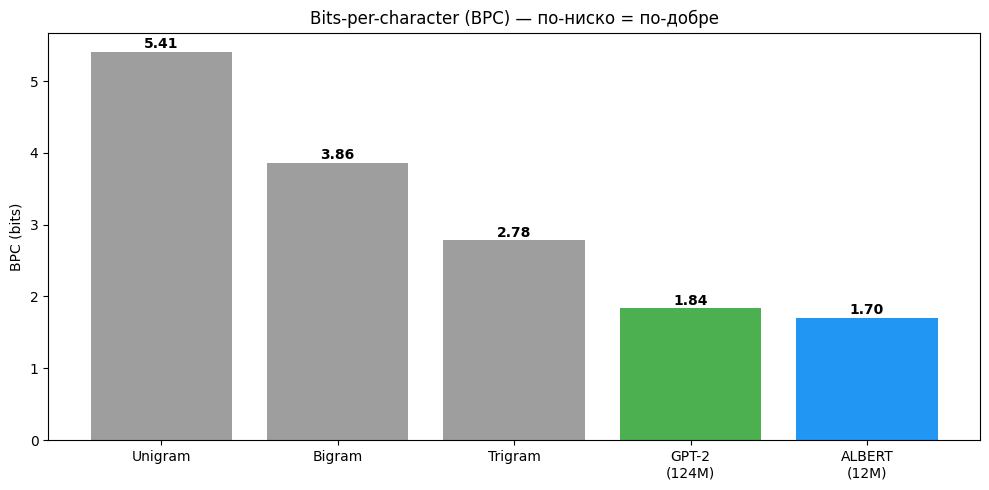

In [18]:
# Визуализация: BPC сравнение
models = ["Unigram", "Bigram", "Trigram", "GPT-2\n(124M)", "ALBERT\n(12M)"]
bpcs = [bpc_unigram, bpc_bigram, bpc_trigram, bpc_gpt2, bpc_albert]
colors = ["#9E9E9E", "#9E9E9E", "#9E9E9E", "#4CAF50", "#2196F3"]

plt.figure(figsize=(10, 5))
bars = plt.bar(models, bpcs, color=colors)
plt.title("Bits-per-character (BPC) — по-ниско = по-добре")
plt.ylabel("BPC (bits)")

for bar, bpc in zip(bars, bpcs):
    plt.text(bar.get_x() + bar.get_width() / 2, bpc + 0.05,
             f"{bpc:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()